# Sampling of the Rosenbrock distribution

In [36]:
import torch
from torch import Tensor
from geodesic_toolbox.cometric import RosenbrockHessian,RosenbrockSoftAbs, RosenbrockScore, RosenbrockRanders, RosenbrockDualRanders
from geodesic_toolbox.samplers import ImplicitRHMCSampler, ImplicitFHMCUnbiased, ImplicitFHMCLegendre
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

In this notebook we aim at benchmarking how our method, FHMC, performs on the sampling of the Rosenbrock distribution : 

\begin{equation}
    \pi(x,y) \propto \exp(-[100(y-x^2)^2+(1-x)^2]/20)
\end{equation}



In [37]:
def rosenborck(z : Tensor) -> Tensor : 
    x = z[:, 0]
    y = z[:, 1]
    return torch.exp(-(100*(y-x**2)**2+(1-x)**2)/20)

## Riemannian Hamiltonian Monte Carlo Sampling

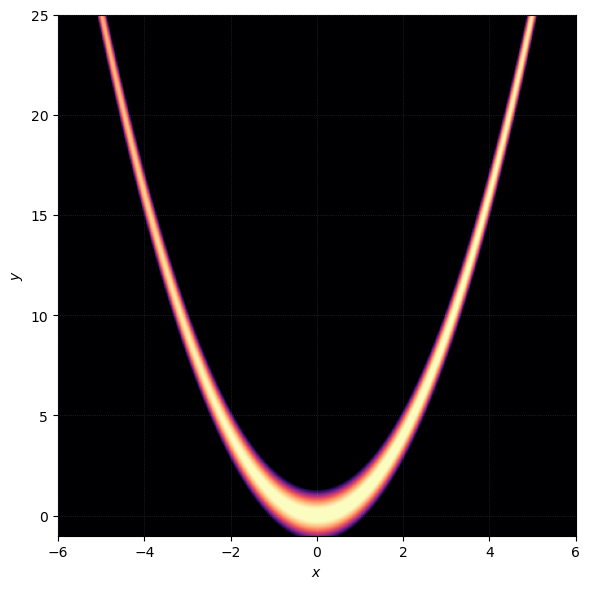

In [38]:
grid_fine = 400

xg = np.linspace(-6, 6, grid_fine)
yg = np.linspace(-1, 25, grid_fine)
xx, yy = np.meshgrid(xg, yg)

log_pi  = -(100 * (yy - xx**2)**2 + (1 - xx)**2) / 20
vmax_pi = np.percentile(log_pi, 99)
vmin_pi = np.percentile(log_pi, 92)

fig, ax = plt.subplots(figsize=(6, 6))

im = ax.imshow(
    log_pi,
    origin="lower",
    extent=[xg.min(), xg.max(), yg.min(), yg.max()],
    cmap="magma",
    aspect="auto",
    vmin=vmin_pi,
    vmax=vmax_pi,
    zorder=0,
)

ax.grid(True, linestyle=":", linewidth=0.5, color="white", alpha=0.2)
ax.set_axisbelow(False)

ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_xlim(xg.min(), xg.max())
ax.set_ylim(yg.min(), yg.max())
plt.tight_layout()
plt.show()

### Definition of the sampler

In [39]:
class RosenbrockRHMC(ImplicitRHMCSampler):
    def __init__(self, l: int, N_fx: int, gamma: float, N_run: int, std_0: float = 1, bounds: float = 1000, beta_0: float = 1, pbar: bool = False, skip_acceptance: bool = False, threshold_fx: float = 0.00001, alpha : float = 1.):
        cometric = RosenbrockSoftAbs(alpha)
        super().__init__(cometric, l, N_fx, gamma, N_run, std_0, bounds, beta_0, pbar, skip_acceptance, threshold_fx)
    
    def U(self, z):
        x = z[:, 0]
        y = z[:, 1]
        return (100*(y-x**2)**2+(1-x)**2)/20

In [40]:
l = 10
N_fx = 6
gamma = 0.57
N_run = 2000

sampler = RosenbrockRHMC(
    l, 
    N_fx, 
    gamma, 
    N_run,
    pbar = True
)

### Sampling a trajectory

In [41]:
n_traj = 1
z_0 = torch.zeros(n_traj, 2)
z_0 = torch.tensor([[0.4, 0.5]]*n_traj)
torch.manual_seed(0)
traj_rhmc, acc_rhmc = sampler.sample(
    z_0, 
    return_traj = True, 
    progress = True,
    return_acceptance= True
    )
print(f"Acceptance rate: {acc_rhmc:.4f}")

Sampling: 100%|██████████| 2000/2000 [05:16<00:00,  6.31steps/s, acceptance_rate=0.758]

Acceptance rate: 0.7585


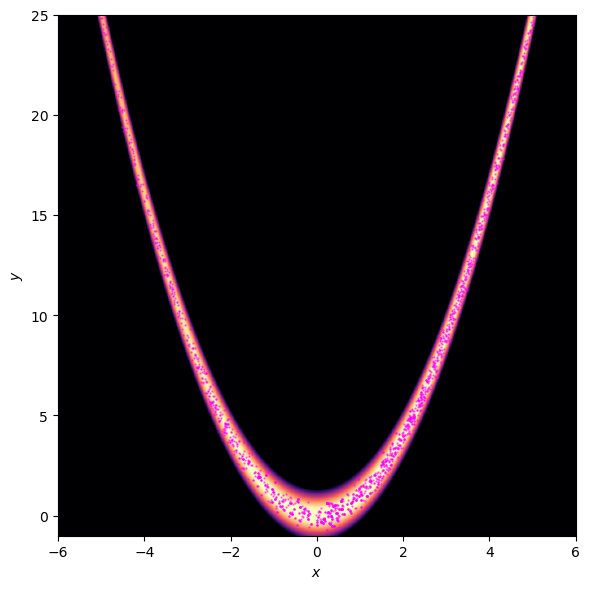

In [54]:
grid_fine = 400

xg = np.linspace(-6, 6, grid_fine)
yg = np.linspace(-1, 25, grid_fine)
xx, yy = np.meshgrid(xg, yg)

log_pi  = -(100 * (yy - xx**2)**2 + (1 - xx)**2) / 20
vmax_pi = np.percentile(log_pi, 99)
vmin_pi = np.percentile(log_pi, 92)

fig, ax = plt.subplots(figsize=(6, 6))

im = ax.imshow(
    log_pi,
    origin="lower",
    extent=[xg.min(), xg.max(), yg.min(), yg.max()],
    cmap="magma",
    aspect="auto",
    vmin=vmin_pi,
    vmax=vmax_pi,
    zorder=0,
)

for i in range(traj_rhmc.shape[0]):
    ax.scatter(traj_rhmc[i, :, 0].numpy(), traj_rhmc[i, :, 1].numpy(),
            c="magenta", s=0.5, alpha=0.5, zorder=3)

ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_xlim(xg.min(), xg.max())
ax.set_ylim(yg.min(), yg.max())
plt.tight_layout()
plt.show()


## Finsler Randers Hamiltonian Monte Carlo Sampling

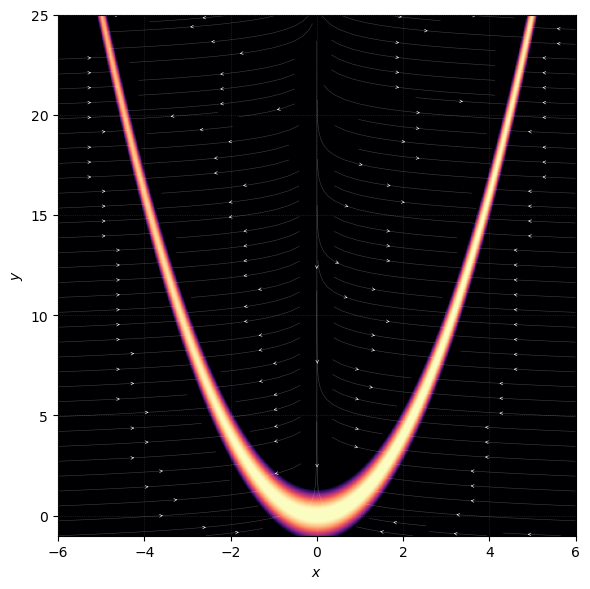

In [49]:
grid_fine   = 400
grid_stream = 100

xg = np.linspace(-6, 6, grid_fine)
yg = np.linspace(-1, 25, grid_fine)
xx, yy = np.meshgrid(xg, yg)

log_pi  = -(100 * (yy - xx**2)**2 + (1 - xx)**2) / 20
vmax_pi = np.percentile(log_pi, 99)
vmin_pi = np.percentile(log_pi, 92)

xg_s = np.linspace(-6, 6, grid_stream)
yg_s = np.linspace(-1, 25, grid_stream)
xx_s, yy_s = np.meshgrid(xg_s, yg_s)

U = 20 * xx_s * (yy_s - xx_s**2) + (1 - xx_s) / 10
V = -10 * (yy_s - xx_s**2)

fig, ax = plt.subplots(figsize=(6, 6))

im = ax.imshow(
    log_pi,
    origin="lower",
    extent=[xg.min(), xg.max(), yg.min(), yg.max()],
    cmap="magma",
    aspect="auto",
    vmin=vmin_pi,
    vmax=vmax_pi,
    zorder=0,
)

sp = ax.streamplot(
    xg_s, yg_s,
    U, V,
    color="white",
    linewidth=0.4,
    density=1.2,
    arrowsize=0.5,
    arrowstyle="->",
    zorder=2,
)
sp.lines.set_alpha(0.25)
sp.arrows.set_alpha(0.15)

ax.grid(True, linestyle=":", linewidth=0.5, color="white", alpha=0.2)
ax.set_axisbelow(False)

ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_xlim(xg.min(), xg.max())
ax.set_ylim(yg.min(), yg.max())
plt.tight_layout()
plt.show()

### Definition of the sampler

In [50]:
class RosenbrockFHMCUnbiased(ImplicitFHMCUnbiased):
    def __init__(self, l: int, N_fx: int, gamma: float, N_run: int,
                 bounds: float = 1e3, std_0: float = 1., beta_0: float = 1.,
                 pbar: bool = False, skip_acceptance: bool = False,
                 reduced_flip: bool = True, alpha: float = 1., beta : float = 1.):
        randers_cometric = RosenbrockDualRanders(alpha=alpha, beta = beta)
        super().__init__(
            randers_cometric=randers_cometric,
            l=l, N_fx=N_fx, gamma=gamma, N_run=N_run,
            bounds=bounds, std_0=std_0, beta_0=beta_0,
            pbar=pbar, skip_acceptance=skip_acceptance,
            reduced_flip=reduced_flip,
        )

    def U(self, z):
        x, y = z[:, 0], z[:, 1]
        return (100*(y - x**2)**2 + (1 - x)**2) / 20
    
    def K(self, p: Tensor, z: Tensor) -> Tensor:
        d   = z.shape[1]
        eps = self.randers_cometric.epsilon
        _, w_star, G_star = self.randers_cometric._shared(z)   # ONE eigh

        # F* without re-eigh
        v_norm = torch.einsum("bi,bij,bj->b", p, G_star, p).sqrt()
        F_star = v_norm + torch.einsum("bi,bi->b", w_star, p)
        F_star_sq = F_star ** 2 + eps ** 2     # avoid the throw-away outer sqrt

        # BH terms via one Cholesky of G* (G* is already in hand)
        L = torch.linalg.cholesky(G_star)
        y = torch.linalg.solve_triangular(L, w_star.unsqueeze(-1), upper=False).squeeze(-1)
        alpha = torch.einsum("bi,bi->b", y, y)
        logdet_G_star = 2.0 * torch.diagonal(L, dim1=-2, dim2=-1).log().sum(-1)

        return (0.5 * F_star_sq
                - 0.5 * (d + 1) * torch.log1p(-alpha)
                - 0.5 * logdet_G_star
                + 0.5 * d * self.log2pi)

    def H(self, z: Tensor, p: Tensor) -> Tensor:
        return self.U(z) + self.K(p, z)


    def H_tilde(self, z: Tensor, p: Tensor) -> Tensor:
        d   = z.shape[1]
        eps = self.randers_cometric.epsilon

        G_inv, w_star, G_star = self.randers_cometric._shared(z)   # ONE eigh

        # ── logdet G* and α_s via one Cholesky of G* ──────────────────────────
        L             = torch.linalg.cholesky(G_star)
        y             = torch.linalg.solve_triangular(
                            L, w_star.unsqueeze(-1), upper=False).squeeze(-1)
        b_sq          = torch.einsum("bi,bi->b", y, y)   # |ω*|²_{G*⁻¹} = 1 – α_s
        alpha_s       = 1.0 - b_sq
        logdet_G_star = 2.0 * torch.diagonal(L, dim1=-2, dim2=-1).log().sum(-1)

        # BCS identity: det G · det G* = α_s^{–(d+1)}
        #   ⟹ ½(d+1) log α_s + ½ log det G = –½ log det G*
        log_sigma_BH  = -0.5 * logdet_G_star

        # ── momentum scalars, without materialising G* ────────────────────────
        p_Ginv_p = torch.einsum("bi,bij,bj->b", p, G_inv, p)   # p^T G^{-1} p
        wstar_p  = torch.einsum("bi,bi->b", w_star, p)          # ω* · p

        # p^T G* p = (ω*·p)² + p^T G^{-1} p / α_s   (from the MDL form of G*)
        riem_norm = (wstar_p**2 + p_Ginv_p / alpha_s).sqrt()
        F_star_sq = (riem_norm + wstar_p)**2 + eps**2
        log_randers_factor = torch.log1p(wstar_p / riem_norm)

        return (
            self.U(z)
            + 0.5  * F_star_sq
            - (d + 1) * log_randers_factor
            + log_sigma_BH
            + 0.5 * d * self.log2pi
        )


### Unbiased sampler without reduced flips

In [51]:
l = 10
N_fx = 6
gamma = 0.57
N_run = 2000
beta = 0.4

sampler_unbiased = RosenbrockFHMCUnbiased(
    l = l, 
    N_fx= N_fx, 
    gamma = gamma, 
    N_run = N_run, 
    beta = beta,
    reduced_flip = False
)

In [52]:
n_traj = 1
z_0 = torch.zeros(n_traj, 2)
z_0 = torch.tensor([[0.4, 0.5]]*n_traj)
torch.manual_seed(0)
traj_fhmc, acc_fhmc, flip_fhmc = sampler_unbiased.sample(
    z_0, 
    return_traj = True, 
    progress = True,
    return_acceptance= True,
    return_flip = True
    )
print(f"Acceptance rate: {acc_fhmc:.4f}")
print(f"Momentum flip rate: {flip_fhmc:.4f}")

Sampling: 100%|██████████| 2000/2000 [09:08<00:00,  3.65steps/s, acceptance_rate=0.245]

Acceptance rate: 0.2450
Momentum flip rate: 0.7550


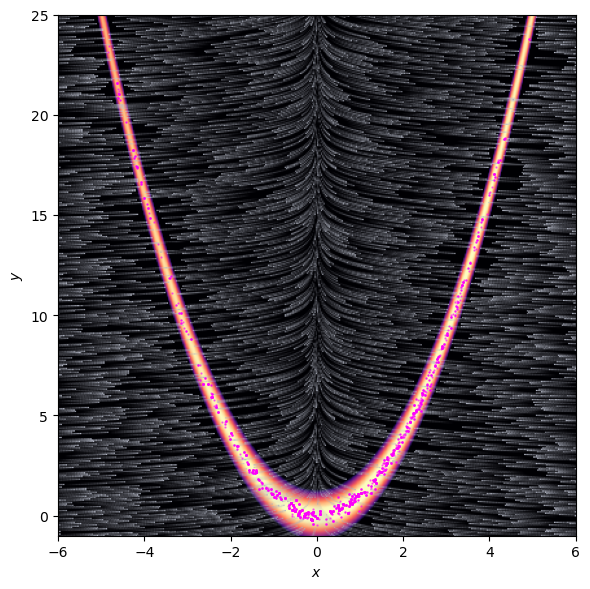

In [57]:
grid_fine = 400

xg = np.linspace(-6, 6, grid_fine)
yg = np.linspace(-1, 25, grid_fine)
xx, yy = np.meshgrid(xg, yg)

log_pi  = -(100 * (yy - xx**2)**2 + (1 - xx)**2) / 20
vmax_pi = np.percentile(log_pi, 99)
vmin_pi = np.percentile(log_pi, 92)

# Randers drift (score) field beta * omega(x) -> sparse OLIC texture
grid_field = xx.shape[0]
pts_field = torch.tensor(np.stack([xx.ravel(), yy.ravel()], axis=1), dtype=torch.float32)
primal_randers = sampler_unbiased.randers_cometric.primal_randers
with torch.no_grad():
    drift_field = primal_randers.beta * primal_randers.omega(pts_field)
U = drift_field[:, 0].numpy().reshape(xx.shape)
V = drift_field[:, 1].numpy().reshape(xx.shape)
speed = np.sqrt(U ** 2 + V ** 2)


def sparse_olic(U, V, density=0.03, n_steps=46, step=0.7, seed=0, decay=0.9):
    """Sparse oriented LIC: droplets smeared into comets that point along the flow.
       Pass U, V in PIXEL units so strokes match the on-screen direction."""
    H, W = U.shape
    mag = np.hypot(U, V); mag[mag == 0] = 1.0
    u, v = U / mag, V / mag
    rng = np.random.default_rng(seed)
    tex = np.zeros((H, W))
    flat = rng.integers(0, H * W, int(density * H * W))
    tex.flat[flat] = rng.uniform(0.6, 1.0, flat.size)
    ys, xs = np.mgrid[0:H, 0:W]

    def sample(f, x, y):
        x0 = np.clip(np.floor(x).astype(int), 0, W - 1); y0 = np.clip(np.floor(y).astype(int), 0, H - 1)
        x1 = np.clip(x0 + 1, 0, W - 1); y1 = np.clip(y0 + 1, 0, H - 1)
        fx, fy = x - x0, y - y0
        return (f[y0, x0] * (1 - fx) * (1 - fy) + f[y0, x1] * fx * (1 - fy)
                + f[y1, x0] * (1 - fx) * fy + f[y1, x1] * fx * fy)

    inten = np.zeros((H, W))
    x = xs.astype(float).copy(); y = ys.astype(float).copy()
    for k in range(n_steps):
        w = (1 - k / n_steps) ** decay
        inten = np.maximum(inten, w * sample(tex, x, y))
        x -= step * sample(u, x, y); y -= step * sample(v, x, y)
    return inten / (inten.max() + 1e-9)


dx = (xg.max() - xg.min()) / (grid_field - 1)
dy = (yg.max() - yg.min()) / (grid_field - 1)
inten = sparse_olic(U / dx, V / dy)
s = np.clip(speed / np.percentile(speed, 98), 0, 1)        # speed -> stroke lightness

extent = [xg.min(), xg.max(), yg.min(), yg.max()]

# magma density background + OLIC score texture composited into one rgb image
n_pi = np.clip((log_pi - vmin_pi) / (vmax_pi - vmin_pi), 0, 1)
img = cm.magma(n_pi)[..., :3].copy()

field_rgb = np.array([0.82, 0.84, 0.90]) * (0.8 + 0.2 * s[..., None])
a_field = np.clip(inten * 0.9, 0, 1)[..., None]
img = img * (1 - a_field) + field_rgb * a_field

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(img, origin="lower", extent=extent, aspect="auto", zorder=0)

for i in range(traj_fhmc.shape[0]):
    ax.scatter(traj_fhmc[i, :, 0].numpy(), traj_fhmc[i, :, 1].numpy(),
            c="magenta", s=0.5, alpha=0.5, zorder=3)

ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_xlim(xg.min(), xg.max())
ax.set_ylim(yg.min(), yg.max())
plt.tight_layout()
plt.show()


### Unbiased Sampler with reduced flip

In [60]:
l = 10
N_fx = 6
gamma = 0.57
N_run = 2000
beta = 0.4

sampler_unbiased_rf = RosenbrockFHMCUnbiased(
    l = l, 
    N_fx= N_fx, 
    gamma = gamma, 
    N_run = N_run, 
    beta = beta
)

In [61]:
n_traj = 1
z_0 = torch.zeros(n_traj, 2)
z_0 = torch.tensor([[0.4, 0.5]]*n_traj)
torch.manual_seed(0)
traj_fhmc_rf, acc_fhmc_rf, flip_fhmc_rf = sampler_unbiased_rf.sample(
    z_0, 
    return_traj = True, 
    progress = True,
    return_acceptance= True,
    return_flip = True
    )
print(f"Acceptance rate: {acc_fhmc_rf:.4f}")
print(f"Momentum flip rate: {flip_fhmc_rf:.4f}")

Sampling: 100%|██████████| 2000/2000 [24:05<00:00,  1.38steps/s, acceptance_rate=0.231]    

Acceptance rate: 0.2305
Momentum flip rate: 0.0790


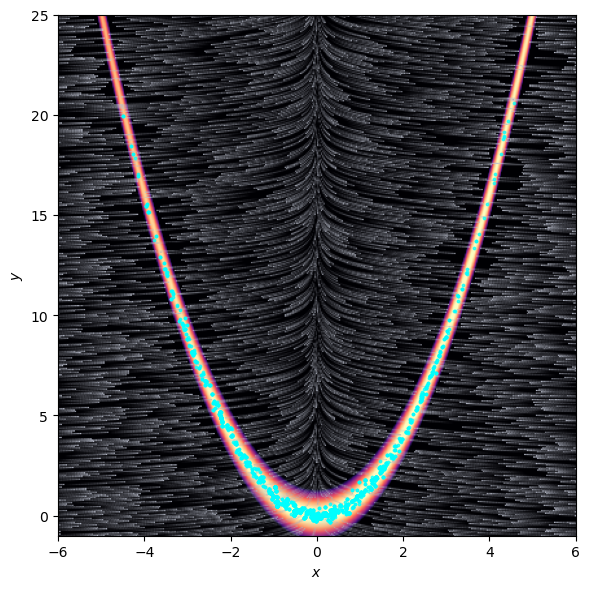

In [62]:
grid_fine = 400

xg = np.linspace(-6, 6, grid_fine)
yg = np.linspace(-1, 25, grid_fine)
xx, yy = np.meshgrid(xg, yg)

log_pi  = -(100 * (yy - xx**2)**2 + (1 - xx)**2) / 20
vmax_pi = np.percentile(log_pi, 99)
vmin_pi = np.percentile(log_pi, 92)

# Randers drift (score) field beta * omega(x) -> sparse OLIC texture
grid_field = xx.shape[0]
pts_field = torch.tensor(np.stack([xx.ravel(), yy.ravel()], axis=1), dtype=torch.float32)
primal_randers = sampler_unbiased_rf.randers_cometric.primal_randers
with torch.no_grad():
    drift_field = primal_randers.beta * primal_randers.omega(pts_field)
U = drift_field[:, 0].numpy().reshape(xx.shape)
V = drift_field[:, 1].numpy().reshape(xx.shape)
speed = np.sqrt(U ** 2 + V ** 2)


def sparse_olic(U, V, density=0.03, n_steps=46, step=0.7, seed=0, decay=0.9):
    """Sparse oriented LIC: droplets smeared into comets that point along the flow.
       Pass U, V in PIXEL units so strokes match the on-screen direction."""
    H, W = U.shape
    mag = np.hypot(U, V); mag[mag == 0] = 1.0
    u, v = U / mag, V / mag
    rng = np.random.default_rng(seed)
    tex = np.zeros((H, W))
    flat = rng.integers(0, H * W, int(density * H * W))
    tex.flat[flat] = rng.uniform(0.6, 1.0, flat.size)
    ys, xs = np.mgrid[0:H, 0:W]

    def sample(f, x, y):
        x0 = np.clip(np.floor(x).astype(int), 0, W - 1); y0 = np.clip(np.floor(y).astype(int), 0, H - 1)
        x1 = np.clip(x0 + 1, 0, W - 1); y1 = np.clip(y0 + 1, 0, H - 1)
        fx, fy = x - x0, y - y0
        return (f[y0, x0] * (1 - fx) * (1 - fy) + f[y0, x1] * fx * (1 - fy)
                + f[y1, x0] * (1 - fx) * fy + f[y1, x1] * fx * fy)

    inten = np.zeros((H, W))
    x = xs.astype(float).copy(); y = ys.astype(float).copy()
    for k in range(n_steps):
        w = (1 - k / n_steps) ** decay
        inten = np.maximum(inten, w * sample(tex, x, y))
        x -= step * sample(u, x, y); y -= step * sample(v, x, y)
    return inten / (inten.max() + 1e-9)


dx = (xg.max() - xg.min()) / (grid_field - 1)
dy = (yg.max() - yg.min()) / (grid_field - 1)
inten = sparse_olic(U / dx, V / dy)
s = np.clip(speed / np.percentile(speed, 98), 0, 1)        # speed -> stroke lightness

extent = [xg.min(), xg.max(), yg.min(), yg.max()]

# magma density background + OLIC score texture composited into one rgb image
n_pi = np.clip((log_pi - vmin_pi) / (vmax_pi - vmin_pi), 0, 1)
img = cm.magma(n_pi)[..., :3].copy()

field_rgb = np.array([0.82, 0.84, 0.90]) * (0.8 + 0.2 * s[..., None])
a_field = np.clip(inten * 0.9, 0, 1)[..., None]
img = img * (1 - a_field) + field_rgb * a_field

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(img, origin="lower", extent=extent, aspect="auto", zorder=0)

for i in range(traj_fhmc_rf.shape[0]):
    ax.scatter(traj_fhmc_rf[i, :, 0].numpy(), traj_fhmc_rf[i, :, 1].numpy(),
            c="cyan", s=3, alpha=0.7, zorder=3)

ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_xlim(xg.min(), xg.max())
ax.set_ylim(yg.min(), yg.max())
plt.tight_layout()
plt.show()


## Autocorrelation comparison

In [ ]:
def acf(chain, max_lag):
    """Normalized autocorrelation at lags 0..max_lag for a 1D array."""
    chain = chain - chain.mean()
    var = np.var(chain)
    return np.array([
        np.mean(chain[:len(chain) - k] * chain[k:]) / var if k > 0 else 1.0
        for k in range(max_lag + 1)
    ])

def ess_from_chain(chain, max_lag):
    """
    ESS = N / IAT,  IAT = 1 + 2 * sum_{k>=1} ACF(k).
    Sum truncated at the first negative lag (Geyer's initial positive sequence).
    """
    ac = acf(chain, max_lag)
    first_neg = np.argmax(ac[1:] < 0)
    cutoff = first_neg if first_neg > 0 else max_lag
    iat = 1.0 + 2.0 * ac[1:cutoff + 1].sum()
    return len(chain) / max(iat, 1.0)

def mean_acf(traj, dim, max_lag):
    """Average ACF over all chains for a given coordinate dimension."""
    return np.mean([acf(traj[i, :, dim].numpy(), max_lag) for i in range(traj.shape[0])], axis=0)

def total_ess(traj, dim, max_lag):
    """Total ESS summed over all chains for a given coordinate dimension."""
    return sum(ess_from_chain(traj[i, :, dim].numpy(), max_lag) for i in range(traj.shape[0]))

def mean_ess(traj, dim, max_lag):
    """Per-chain ESS averaged over chains (same metric as the beta-sweep plot)."""
    return np.mean([ess_from_chain(traj[i, :, dim].numpy(), max_lag) for i in range(traj.shape[0])])

max_lag = 150
lags    = np.arange(max_lag + 1)
n_chains, n_steps = traj_rhmc.shape[0], traj_rhmc.shape[1]
N_total = n_chains * n_steps

# ── ESS summary table ────────────────────────────────────────────────────────
# Mean ESS per chain (averaged over n_chains), matching the metric used in the
# beta-sweep plot below — not the chain-summed ESS.
print(f"{'Sampler':<28} {'ESS x':>8}  {'ESS y':>8}")
print("─" * 50)
for traj, label in [
    (traj_rhmc,    "RHMC"),
    (traj_fhmc_rf, "FHMC (reduced flip)"),
    (traj_fhmc,    "FHMC (no reduced flip)"),
]:
    ex = mean_ess(traj, dim=0, max_lag=max_lag)
    ey = mean_ess(traj, dim=1, max_lag=max_lag)
    print(f"{label:<28} {ex:8.1f}  {ey:8.1f}")

# ── ACF plots with ESS annotation ────────────────────────────────────────────
coords = [("$x$", 0, "steelblue"), ("$y$", 1, "coral")]
fig, axes = plt.subplots(2, 3, figsize=(18, 6), sharey=True, sharex=True)

for row, (coord_name, dim, color) in enumerate(coords):
    for col, (traj, acc, label) in enumerate([
        (traj_rhmc,    acc_rhmc,    "RHMC"),
        (traj_fhmc_rf, acc_fhmc_rf, "FHMC (reduced flip)"),
        (traj_fhmc,    acc_fhmc,    "FHMC (no reduced flip)"),
    ]):
        ac      = mean_acf(traj, dim, max_lag)
        ess_val = total_ess(traj, dim, max_lag)
        ax = axes[row, col]
        ax.bar(lags, ac, width=1.0, color=color, alpha=0.7)
        ax.axhline(0, color="k", linewidth=0.6)
        ax.set_title(f"{label}  (acc={acc:.3f}) — {coord_name}")
        ax.set_ylabel("ACF")
        ax.text(0.97, 0.95, f"ESS = {ess_val:.0f}",
                transform=ax.transAxes, ha="right", va="top", fontsize=9,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85))

for ax in axes[1]:
    ax.set_xlabel("Lag")
plt.suptitle(f"ACF and ESS — {n_chains} chains × {n_steps} steps", fontsize=12)
plt.tight_layout()
plt.show()

## Impact of $\beta$

In [ ]:
import os
from concurrent.futures import ProcessPoolExecutor, as_completed

import tqdm

from rosenbrock_beta_worker import eval_beta_traj

l = 2
gamma = 0.57
N_run = 1000
n_traj = 100
d = 2
seed = None  # same seed as the RHMC/FHMC baseline cells above, so beta=0 is a
          # like-for-like comparison instead of an independent MC realization
          # (each beta runs in its own process with otherwise-independent RNG).

# Same z_0 and ESS estimator (Geyer's ess_from_chain / max_lag) as the RHMC/FHMC
# comparison above, so the beta=0 point here is directly comparable to the RHMC
# numbers (FHMC is supposed to reduce to RHMC at beta=0).
max_lag = 150  # must match the autocorrelation-comparison cell above
z_0_beta = torch.tensor([[0.4, 0.5]] * n_traj)

betas = np.linspace(0.0, 1.0, 11)

def per_chain_ess(traj, dim, max_lag):
    """Per-chain ESS for one coordinate, using the same Geyer estimator as above."""
    return np.array([ess_from_chain(traj[i, :, dim].numpy(), max_lag) for i in range(traj.shape[0])])

# Per-chain, per-coordinate ESS for each beta: shape (len(betas), n_traj, d).
evals_full    = np.zeros((len(betas), n_traj, d))   # reduced_flip = False
evals_reduced = np.zeros((len(betas), n_traj, d))   # reduced_flip = True
acc_full,  acc_reduced  = np.zeros(len(betas)), np.zeros(len(betas))

# One worker process per (beta, flip-variant) job, capped by the number of
# cores; each worker stays single-threaded so the processes don't
# oversubscribe the CPU.
n_workers = min(os.cpu_count(), 2 * len(betas))

jobs = {}
with ProcessPoolExecutor(max_workers=n_workers) as executor:
    for i, beta in enumerate(betas):
        jobs[executor.submit(eval_beta_traj, beta, gamma, l, False, N_run, n_traj, z_0_beta, 1, seed)] = (i, "full")
        jobs[executor.submit(eval_beta_traj, beta, gamma, l, True,  N_run, n_traj, z_0_beta, 1, seed)] = (i, "reduced")

    for future in tqdm.tqdm(as_completed(jobs), total=len(jobs)):
        i, kind = jobs[future]
        traj_beta, acc, flip = future.result()
        ess_x = per_chain_ess(traj_beta, dim=0, max_lag=max_lag)
        ess_y = per_chain_ess(traj_beta, dim=1, max_lag=max_lag)
        if kind == "full":
            evals_full[i, :, 0], evals_full[i, :, 1] = ess_x, ess_y
            acc_full[i] = acc
        else:
            evals_reduced[i, :, 0], evals_reduced[i, :, 1] = ess_x, ess_y
            acc_reduced[i] = acc

In [ ]:
color_full, color_reduced = "#1f77b4", "#d62728"
coord_names = ["x", "y"]


def central_and_band(per_chain_vec, stat: str = "mean"):
    """Central tendency across chains + STANDARD ERROR band (not raw std).

    per_chain_vec : (grid_res, batch_size)  -- one coordinate's ESS per chain.
    The uncertainty on the *mean* is std/sqrt(batch); that is what should be
    shaded to judge whether a beta-trend is real (raw std is per-chain dispersion
    and makes every beta overlap).
    """
    B = per_chain_vec.shape[1]
    central = np.median(per_chain_vec, axis=1) if stat == "median" else per_chain_vec.mean(axis=1)
    sem = per_chain_vec.std(axis=1, ddof=0) / B ** 0.5
    return central, sem


for dim in range(evals_full.shape[-1]):
    fig, ax = plt.subplots(figsize=(7, 5))

    for mat, color, label in [
        (evals_full[..., dim],    color_full,    "FHMC"),
        (evals_reduced[..., dim], color_reduced, "FHMC (reduced flips)"),
    ]:
        central, sem = central_and_band(mat, stat="mean")
        ax.plot(betas, central, label=label, color=color, linewidth=2, marker="o", markersize=4)
        ax.fill_between(betas, central - sem, central + sem, color=color, alpha=0.2)

    # beta = 0 is RHMC; shade the degenerate high-beta region.
    ax.axvline(0.0, color="grey", linestyle="--", linewidth=1, alpha=0.6)

    ax.grid(True, linestyle=":", color="grey", alpha=0.6)
    ax.set_axisbelow(True)
    ax.set_xlabel(r"$\beta$")
    ax.set_ylabel(r"ESS  (mean over chains)")
    ax.tick_params(length=0)

    ax.text(0.01, ax.get_ylim()[1], r"$\beta=0$ is RHMC", va="top", fontsize=9, color="grey")
    ax.legend(frameon=True, facecolor="white", edgecolor="black")

    plt.tight_layout()
    plt.show()